LSTM model with 5 feature (Open, High, Low, Close, Volume) with 15 minutes of data

Importing all the necessary Libraries 

In [41]:
# Standard library
import os
import random
from datetime import datetime, timedelta

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [42]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

Loading past 10 years of APPL OHLCV data from CSV file (downloaded from Market Data API)

In [43]:
#Loading the sentiment CSV file before passing it to the LSTM
data = pd.read_csv("AAPL_15min_OHLCV.csv")

#Converts the timestamp column into a proper datetime object, which is easier for manipulation later on
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Define feature 
features = ['close', 'open', 'high', 'low', 'volume']

#Extract specific columns from your DataFrame and do a datatype conversion as pandas typically use float64, but neural networks use float32
feature_data = data[features].astype(np.float32).values
# Store timestamps (useful for plotting / alignment)
datetime_index = data['timestamp'].values

print(data.head())

            timestamp     open    high      low     close   volume
0 2015-01-02 14:30:00  111.390  111.44  110.629  110.8610  3846731
1 2015-01-02 14:45:00  110.860  110.86  108.650  109.5100  6487368
2 2015-01-02 15:00:00  109.490  109.71  109.200  109.4301  2926205
3 2015-01-02 15:15:00  109.435  109.47  108.770  109.1050  3096434
4 2015-01-02 15:30:00  109.130  109.15  107.350  107.7299  4217519


In [44]:
# Get the number of close prices
print(f"Number of close prices: {len(feature_data)}")

Number of close prices: 71793


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [45]:
total_size = len(feature_data)

#Calculating the split size
#First 70% of the total data to be for training then the next 15% for validation, leaving the remaining 15% for testing
train_size = int(len(feature_data) * 0.70)
val_size   = int(len(feature_data) * 0.15)

#Splitting the data
train_data = feature_data[:train_size]
val_data = feature_data[train_size:train_size + val_size]
test_data = feature_data[train_size + val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_data)} samples ({len(train_data)/total_size:.2%})")
print(f"Validation set : {len(val_data)} samples ({len(val_data)/total_size:.2%})")
print(f"Test set       : {len(test_data)} samples ({len(test_data)/total_size:.2%})")

print("Train:", train_data.shape)
print("Val  :", val_data.shape)
print("Test :", test_data.shape)

print("\nCheck sum:", len(train_data) + len(val_data) + len(test_data))

Total samples: 71793

Dataset sizes:
Training set   : 50255 samples (70.00%)
Validation set : 10768 samples (15.00%)
Test set       : 10770 samples (15.00%)
Train: (50255, 5)
Val  : (10768, 5)
Test : (10770, 5)

Check sum: 71793


Normalizing my data using a Min-Max Scaler. But only using only the training data as the scaler to prevent data leaks. Need to Scale ALL features

In [46]:
#Calculate the number of features, and create a seperate scaler for each feature
num_features = train_data.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

#Fit each scaler on only the training data for that specific column - this avoids data leaks
for i, scaler in enumerate(scalers):
    scaler.fit(train_data[:, [i]])

#Transform each column individually using its corresponding scaler
#np.hstack then stacks the scaled columns back together horizontally
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#All three datasets are transformed using the scalers fitted on the training data
train_scaled = scale_data(train_data, scalers)
val_scaled = scale_data(val_data, scalers)
test_scaled = scale_data(test_data, scalers)

print("Train scaled min/max:", train_scaled.min(), train_scaled.max())
print("Val   scaled min/max:", val_scaled.min(), val_scaled.max())
print("Test  scaled min/max:", test_scaled.min(), test_scaled.max())

Train scaled min/max: 0.0 1.0000001
Val   scaled min/max: 0.010080755 0.81538886
Test  scaled min/max: 0.0031608166 0.75775695


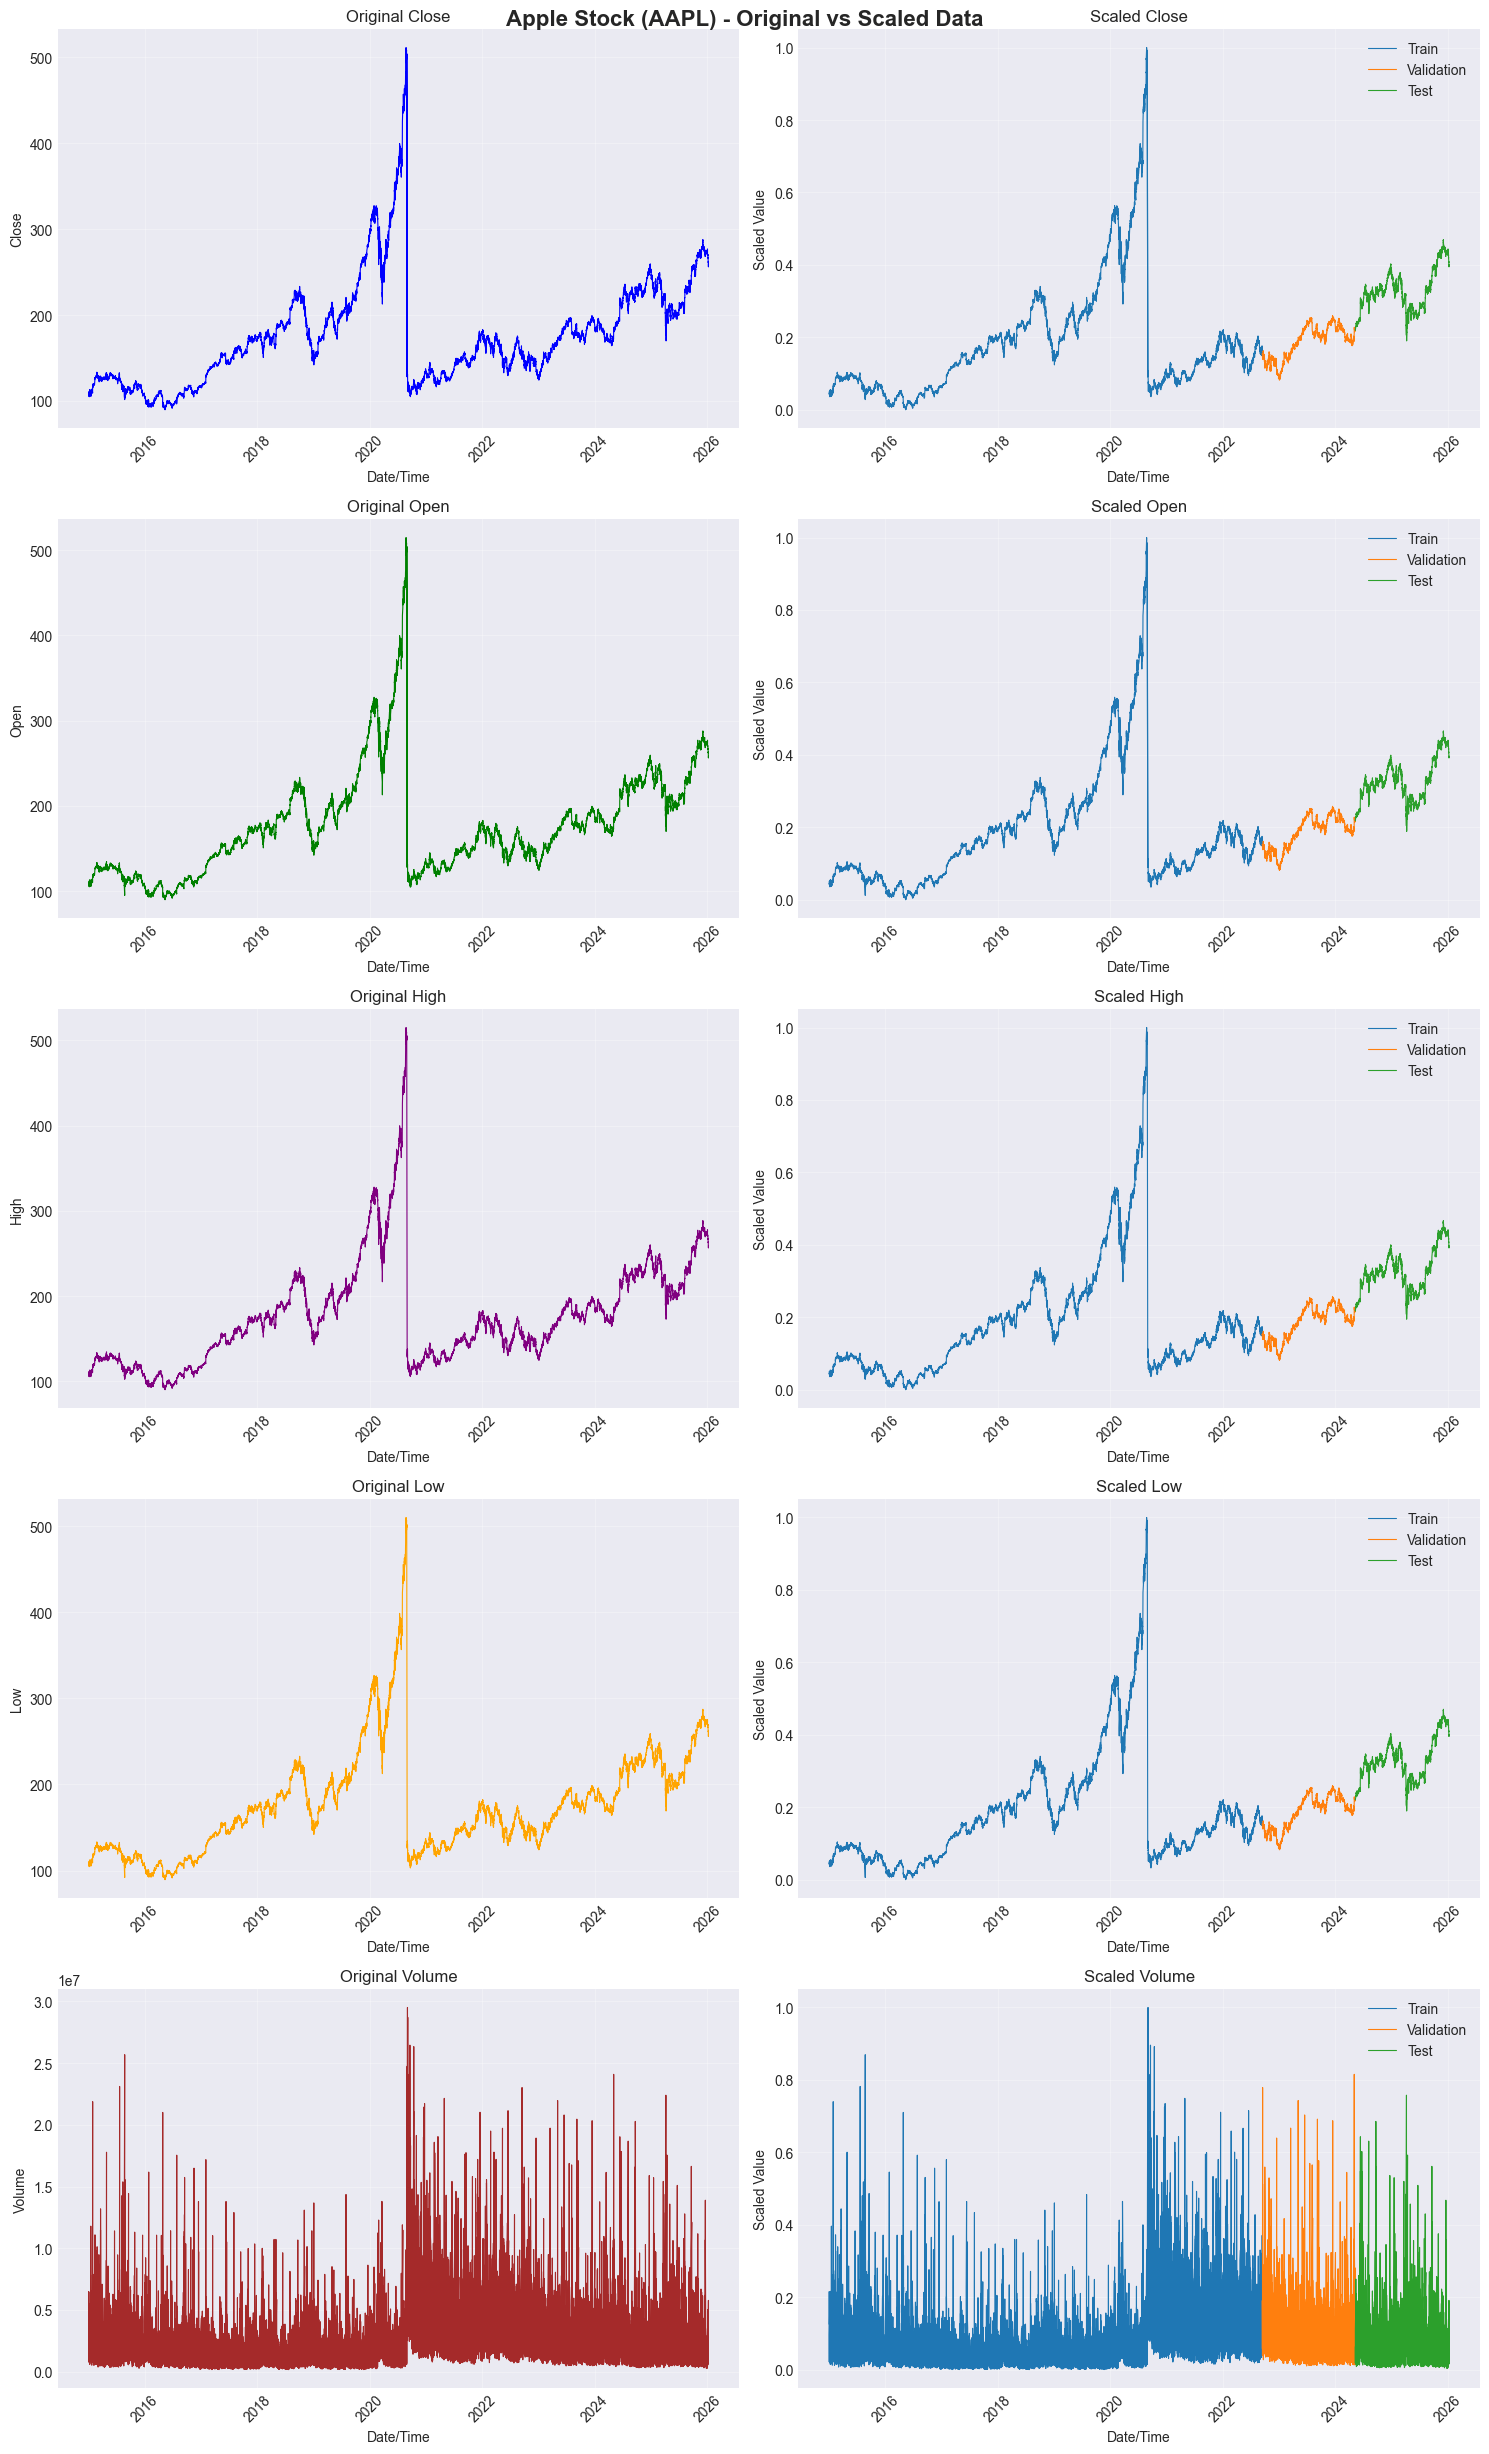

In [47]:
# Reconstructing datetime splits to match data splits
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_data.shape[1]

# Create 5x2 subplot layout for both features
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume']
colors = ['blue', 'green', 'purple', 'orange', 'brown']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, feature_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

In [48]:
def create_multifeature_dataset(data, time_step = 96):
    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  # input grabs all the columns
        y.append(data[i + time_step, 0])  # Predict Close price only

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 96

X_train, y_train = create_multifeature_dataset(train_scaled, time_step)
X_val, y_val     = create_multifeature_dataset(val_scaled, time_step)
X_test, y_test   = create_multifeature_dataset(test_scaled, time_step)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")


Shapes of LSTM datasets:
X_train: (50159, 96, 5), y_train: (50159,)
X_val  : (10672, 96, 5), y_val  : (10672,)
X_test : (10674, 96, 5), y_test : (10674,)


In [49]:
model = Sequential()

#Build the model

#layer 1
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add((LSTM(units=96, return_sequences=True, kernel_regularizer=l2(1e-4))))
model.add(Dropout(0.25))

model.add((LSTM(units=64, return_sequences=False, kernel_regularizer=l2(1e-4))))
model.add(Dropout(0.25))

model.add(Dense(units=1))

#compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mean_squared_error', metrics=['MAE'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Reduce learning rate by half when triggered
    patience=3,          # Wait 3 epochs with no improvement before reducing       
    verbose=1            # means it will print a message whenever the learning rate is reduced
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=50,
    batch_size=64,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 171s 209ms/step - MAE: 0.0226 - loss: 0.0035 - val_MAE: 0.0473 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 2/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 155s 197ms/step - MAE: 0.0267 - loss: 0.0020 - val_MAE: 0.0461 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 3/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 146s 186ms/step - MAE: 0.0233 - loss: 0.0016 - val_MAE: 0.0319 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 220s 281ms/step - MAE: 0.0197 - loss: 0.0012 - val_MAE: 0.0142 - val_loss: 6.0467e-04 - learning_rate: 0.0010
Epoch 5/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 226s 288ms/step - MAE: 0.0153 - loss: 8.4042e-04 - val_MAE: 0.0046 - val_loss: 3.0435e-04 - learning_rate: 0.0010
Epoch 6/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 149s 190ms/step - MAE: 0.0141 - loss: 6.6991e-04 - val_MAE: 0.0212 - val_loss: 8.0430e-04 - learning_rate: 0.0010
Epoch 7/50
784/784 ━━━━━━━━━━━━━━━━━━━━ 121s 155ms/step - MAE: 0.0165 - loss: 9.0848e-04 - val_MAE: 0.00

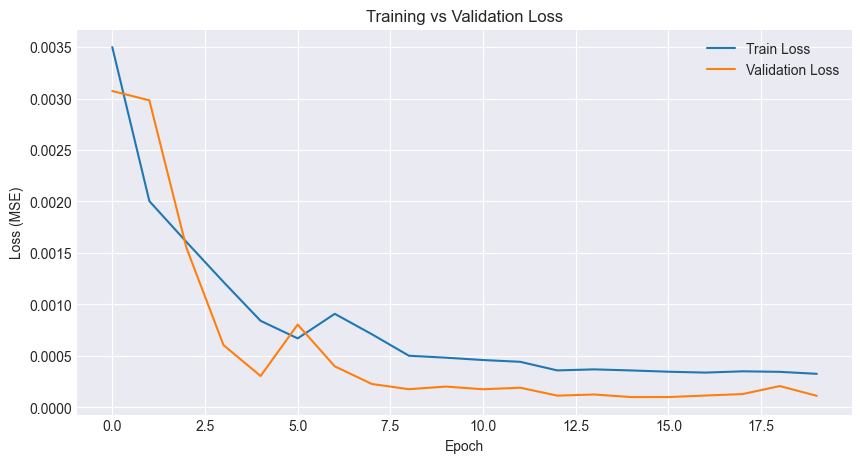

In [50]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predicitions

In [51]:
#This gets the predictions from the model - but these are scaled from (0-1 range) beacuse the model was trained on scaled data
predictions_scaled = model.predict(X_test)

# Inverse transform reverses the scaling applied earlier and converts predictions from 0-1 range back to actual dollar values
predictions = scalers[0].inverse_transform(predictions_scaled)
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

# Flatten the 2D array back to 1D arrays which is easier for metrics calculations
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

# Calculate metrics on unscaled data
#RMSE (Root Mean Squared Error): Average prediction error, penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))

#MAE (Mean Absolute Error): Average absolute difference between predicted and actual prices
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE): ${mae:.2f}")


334/334 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step

Unscaled Root Mean Squared Error (RMSE): $1.74
Unscaled Mean Absolute Error (MAE): $1.23


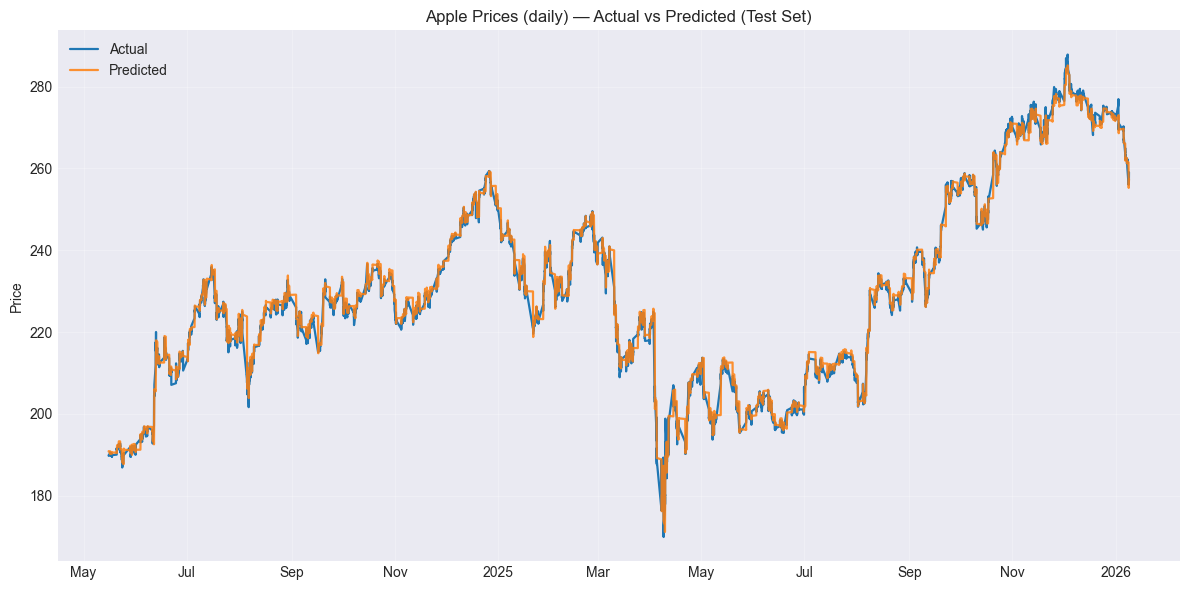

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1) Recompute sizes from your already-split arrays
time_step   = 30
total_samples_train = len(X_train)
total_samples_val = len(X_val)
total_samples_test = len(X_test)

train_end = int(len(feature_data) * 0.70)
val_end = int(len(feature_data) * 0.85)
# test starts at val_end

# The first y_test corresponds to datetime_index[val_end + time_step]
y_test_start_idx = val_end + time_step
y_test_end_idx = y_test_start_idx + len(y_test)

# 4) Slice your dates to match y_test length
dates_test = datetime_index[-len(predictions):]

# 4) Plot with real dates on the x-axis
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled.flatten(), label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions.flatten(), label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.legend()

# Nice datetime formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show() 

Checking the Accuracy of my model:

In [53]:
# --- Directional Accuracy ---

# Actual and predicted price changes
actual_direction = np.sign(np.diff(y_test_unscaled))
predicted_direction = np.sign(np.diff(predictions))

# Directional accuracy
directional_accuracy = np.mean(actual_direction == predicted_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%") 

Directional Accuracy: 49.45%


In [54]:
# --- MAPE-based Accuracy ---

mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100
accuracy_mape = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"MAPE-based Accuracy: {accuracy_mape:.2f}%")

MAPE: 0.55%
MAPE-based Accuracy: 99.45%
